# 02 - Data Cleaning

This notebook cleans the raw Online Retail II dataset and prepares it for exploratory data analysis and customer segmentation.


In [20]:
import pandas as pd
from typing import Optional


class DataCleaner:

    def __init__(self, verbose=True):
        self.verbose = verbose
        self.cleaning_report = {
            "initial_shape": None,
            "final_shape": None,
            "steps": []
        }

    def _record_step(self, name, before, after):
        self.cleaning_report["steps"].append({
            "step": name,
            "rows_before": before,
            "rows_after": after,
            "rows_removed": before - after
        })

        if self.verbose:
            print(f"{name}: {before:,} -> {after:,}")

    def clean_data(
        self,
        df: pd.DataFrame,
        remove_outliers=False,
        outlier_columns: Optional[list] = None
    ):

        df = df.copy()

        self.cleaning_report["initial_shape"] = df.shape

        # Remove missing customer IDs
        before = len(df)
        df = df.dropna(subset=["Customer ID"])
        self._record_step(
            "Remove missing Customer ID",
            before,
            len(df)
        )

        # Remove cancelled invoices
        before = len(df)
        df = df[
            ~df["Invoice"].astype(str).str.startswith("C")
        ]
        self._record_step(
            "Remove cancelled transactions",
            before,
            len(df)
        )

        # Remove invalid quantities
        before = len(df)
        df = df[df["Quantity"] > 0]
        self._record_step(
            "Remove invalid quantities",
            before,
            len(df)
        )

        # Remove invalid prices
        before = len(df)
        df = df[df["Price"] > 0]
        self._record_step(
            "Remove invalid prices",
            before,
            len(df)
        )

        # Remove duplicate rows
        before = len(df)
        df = df.drop_duplicates()
        self._record_step(
            "Remove duplicates",
            before,
            len(df)
        )

        # Create revenue
        df["Revenue"] = df["Quantity"] * df["Price"]

        # Optional outlier removal
        if remove_outliers and outlier_columns:

            for column in outlier_columns:

                if column not in df.columns:
                    continue

                q1 = df[column].quantile(0.25)
                q3 = df[column].quantile(0.75)
                iqr = q3 - q1

                lower = q1 - 1.5 * iqr
                upper = q3 + 1.5 * iqr

                before = len(df)

                df = df[
                    (df[column] >= lower) &
                    (df[column] <= upper)
                ]

                self._record_step(
                    f"Remove outliers from {column}",
                    before,
                    len(df)
                )

        self.cleaning_report["final_shape"] = df.shape

        return df

    def get_cleaning_report(self):
        return self.cleaning_report

    def save_cleaning_report(self, file_path):

        import json

        report = self.cleaning_report.copy()

        initial_rows = report["initial_shape"][0]
        final_rows = report["final_shape"][0]

        report["summary"] = {
            "initial_rows": initial_rows,
            "final_rows": final_rows,
            "rows_removed": initial_rows - final_rows,
            "retention_percentage": round(
                final_rows / initial_rows * 100,
                2
            )
        }

        with open(file_path, "w") as file:
            json.dump(
                report,
                file,
                indent=4,
                default=str
            )


def validate_cleaned_data(df):

    validation = {
        "has_customer_id": df["Customer ID"].notna().all(),
        "positive_quantities": (df["Quantity"] > 0).all(),
        "positive_prices": (df["Price"] > 0).all(),
        "no_cancelled_invoices": (
            ~df["Invoice"]
            .astype(str)
            .str.startswith("C")
            .any()
        ),
        "has_revenue": "Revenue" in df.columns,
        "no_duplicates": not df.duplicated().any(),
        "no_missing_values": not df.isna().any().any()
    }

    validation["all_checks_passed"] = all(
        validation.values()
    )

    return validation


def get_cleaning_summary(df_before, df_after):

    summary = pd.DataFrame({
        "Metric": [
            "Rows",
            "Columns",
            "Unique Customers",
            "Unique Products",
            "Unique Invoices",
            "Missing Values",
            "Duplicates"
        ],
        "Before": [
            len(df_before),
            len(df_before.columns),
            df_before["Customer ID"].nunique(),
            df_before["StockCode"].nunique(),
            df_before["Invoice"].nunique(),
            df_before.isna().sum().sum(),
            df_before.duplicated().sum()
        ],
        "After": [
            len(df_after),
            len(df_after.columns),
            df_after["Customer ID"].nunique(),
            df_after["StockCode"].nunique(),
            df_after["Invoice"].nunique(),
            df_after.isna().sum().sum(),
            df_after.duplicated().sum()
        ]
    })

    return summary


In [21]:
df_raw = load_data(
    "../data/raw/online_retail_II.xlsx",
    sheet_name="Year 2009-2010"
)

original_shape = df_raw.shape

print("Shape:", df_raw.shape)

df_raw.head()


Loading dataset from: ../data/raw/online_retail_II.xlsx
Sheet: Year 2009-2010

✓ Dataset loaded successfully!
  Shape: 525,461 rows × 8 columns
  Memory: 122.87 MB

Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [22]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [23]:
df_raw.describe()


,Quantity,InvoiceDate,Price,Customer ID
count,525461.00,525461,525461.00,417534.00
mean,10.34,2010-06-28 11:37:36.845018,4.69,15360.65
min,-9600.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-03-21 12:20:00,1.25,13983.00
50%,3.00,2010-07-06 09:51:00,2.10,15311.00
75%,10.00,2010-10-15 12:45:00,4.21,16799.00
max,19152.00,2010-12-09 20:01:00,25111.09,18287.00
std,107.42,NaN,146.13,1680.81


In [24]:
df_raw.isna().sum()


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

print("Missing Customer ID:", df_raw["Customer ID"].isna().sum())

print(
    "Cancelled transactions:",
    df_raw["Invoice"].astype(str).str.startswith("C").sum()
)

print(
    "Invalid quantities:",
    (df_raw["Quantity"] <= 0).sum()
)

print(
    "Invalid prices:",
    (df_raw["Price"] <= 0).sum()
)

print(
    "Duplicate rows:",
    df_raw.duplicated().sum()
)


In [25]:
cleaner = DataCleaner(verbose=True)

df_cleaned = cleaner.clean_data(
    df_raw,
    remove_outliers=False
)

cleaning_report = cleaner.get_cleaning_report()

print("\nCleaned shape:", df_cleaned.shape)


Remove missing Customer ID: 525,461 -> 417,534
Remove cancelled transactions: 417,534 -> 407,695
Remove invalid quantities: 407,695 -> 407,695
Remove invalid prices: 407,695 -> 407,664
Remove duplicates: 407,664 -> 400,916

Cleaned shape: (400916, 9)


In [26]:
df_cleaned.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,30.00


In [27]:
df_cleaned.info()


<class 'pandas.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400916 non-null  object        
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[us]
 5   Price        400916 non-null  float64       
 6   Customer ID  400916 non-null  float64       
 7   Country      400916 non-null  str           
 8   Revenue      400916 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), object(3), str(1)
memory usage: 30.6+ MB


In [28]:
df_cleaned.isna().sum()


Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64

In [29]:
validation_results = validate_cleaned_data(
    df_cleaned
)

pd.Series(validation_results)


has_customer_id          True
positive_quantities      True
positive_prices          True
no_cancelled_invoices    True
has_revenue              True
no_duplicates            True
no_missing_values        True
all_checks_passed        True
dtype: bool

In [30]:
print("Validation passed:", validation_results["all_checks_passed"])


Validation passed: True


In [31]:
print("Rows before:", len(df_raw))
print("Rows after:", len(df_cleaned))

print(
    "Rows removed:",
    len(df_raw) - len(df_cleaned)
)

print(
    "Retention rate:",
    f"{len(df_cleaned) / len(df_raw) * 100:.2f}%"
)


Rows before: 525461
Rows after: 400916
Rows removed: 124545
Retention rate: 76.30%


In [32]:
df_cleaned[["Quantity", "Price", "Revenue"]].describe()


,Quantity,Price,Revenue
count,400916.00,400916.00,400916.00
mean,13.77,3.31,21.95
std,97.64,35.05,77.76
min,1.00,0.00,0.00
25%,2.00,1.25,5.00
50%,5.00,1.95,12.50
75%,12.00,3.75,19.50
max,19152.00,10953.50,15818.40


In [33]:
print(
    "Total revenue:",
    f"£{df_cleaned['Revenue'].sum():,.2f}"
)

print(
    "Average revenue:",
    f"£{df_cleaned['Revenue'].mean():,.2f}"
)

print(
    "Median revenue:",
    f"£{df_cleaned['Revenue'].median():,.2f}"
)


Total revenue: £8,798,233.74
Average revenue: £21.95
Median revenue: £12.50


In [34]:
comparison = get_cleaning_summary(
    df_raw,
    df_cleaned
)

comparison


,Metric,Before,After
0,Rows,525461,400916
1,Columns,8,9
2,Unique Customers,4383,4312
3,Unique Products,4632,4017
4,Unique Invoices,28816,19213
5,Missing Values,110855,0
6,Duplicates,6865,0


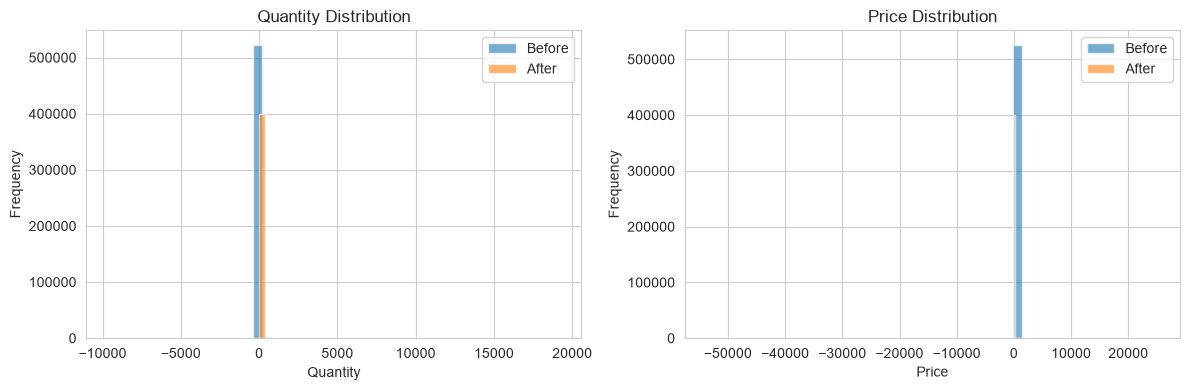

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df_raw["Quantity"],
    bins=50,
    alpha=0.6,
    label="Before"
)

axes[0].hist(
    df_cleaned["Quantity"],
    bins=50,
    alpha=0.6,
    label="After"
)

axes[0].set_title("Quantity Distribution")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(
    df_raw["Price"],
    bins=50,
    alpha=0.6,
    label="Before"
)

axes[1].hist(
    df_cleaned["Price"],
    bins=50,
    alpha=0.6,
    label="After"
)

axes[1].set_title("Price Distribution")
axes[1].set_xlabel("Price")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()


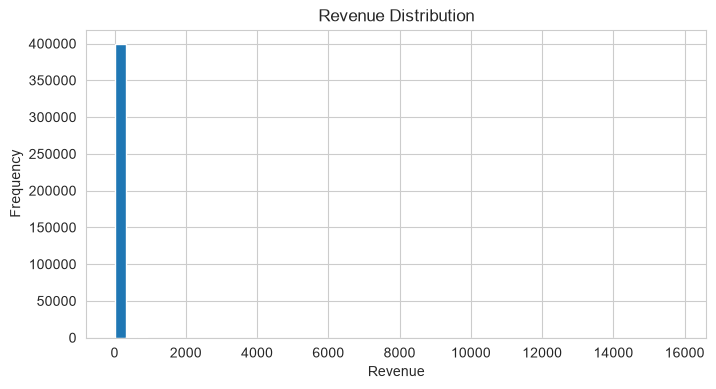

In [36]:
plt.figure(figsize=(8, 4))

plt.hist(
    df_cleaned["Revenue"],
    bins=50
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()


In [37]:
steps = pd.DataFrame(
    cleaning_report["steps"]
)

steps


,step,rows_before,rows_after,rows_removed
0,Remove missing Customer ID,525461,417534,107927
1,Remove cancelled transactions,417534,407695,9839
2,Remove invalid quantities,407695,407695,0
3,Remove invalid prices,407695,407664,31
4,Remove duplicates,407664,400916,6748


In [38]:
import os

os.makedirs("../data/processed", exist_ok=True)

save_dataframe(
    df_cleaned,
    "../data/processed/cleaned_transactions.csv",
    file_format="csv"
)


✓ Data saved to: ../data/processed/cleaned_transactions.csv
  File size: 114.79 MB


In [39]:
os.makedirs("../reports", exist_ok=True)

cleaner.save_cleaning_report(
    "../reports/cleaning_report.json"
)


In [40]:
summary_report = {
    "input_file": "data/raw/online_retail_II.xlsx",
    "output_file": "data/processed/cleaned_transactions.csv",
    "original_rows": int(len(df_raw)),
    "cleaned_rows": int(len(df_cleaned)),
    "rows_removed": int(len(df_raw) - len(df_cleaned)),
    "retention_rate": round(
        len(df_cleaned) / len(df_raw) * 100,
        2
    ),
    "validation_passed": bool(
        validation_results["all_checks_passed"]
    ),
    "unique_customers": int(
        df_cleaned["Customer ID"].nunique()
    ),
    "unique_products": int(
        df_cleaned["StockCode"].nunique()
    ),
    "unique_invoices": int(
        df_cleaned["Invoice"].nunique()
    ),
    "unique_countries": int(
        df_cleaned["Country"].nunique()
    ),
    "total_revenue": float(
        df_cleaned["Revenue"].sum()
    )
}

save_json(
    summary_report,
    "../reports/cleaning_summary.json"
)


✓ JSON saved to: ../reports/cleaning_summary.json


In [41]:
print("Final dataset shape:", df_cleaned.shape)
print("Missing values:", df_cleaned.isna().sum().sum())
print("Duplicate rows:", df_cleaned.duplicated().sum())
print("Unique customers:", df_cleaned["Customer ID"].nunique())
print("Unique products:", df_cleaned["StockCode"].nunique())
print("Unique invoices:", df_cleaned["Invoice"].nunique())
print("Unique countries:", df_cleaned["Country"].nunique())
print(
    "Total revenue:",
    f"£{df_cleaned['Revenue'].sum():,.2f}"
)


Final dataset shape: (400916, 9)
Missing values: 0
Duplicate rows: 0
Unique customers: 4312
Unique products: 4017
Unique invoices: 19213
Unique countries: 37
Total revenue: £8,798,233.74
